<a href="https://colab.research.google.com/github/Wandersonelias/notebooks/blob/master/Pratica_02_UC3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import requests
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay,precision_score,recall_score, sco
from xgboost import XGBClassifier
from scipy.stats import uniform

In [ ]:
#Criando uma session para facilitar o download
session = requests.session()


In [ ]:
#Função para baixar os dados do github e gravar como csv
def carregar_dados(url_base,filename):
  if os.path.isfile(filename):
    print("Arquivo existe - carregando para o Dataframe")
    df = pd.read_csv(filename)
  else:
    response = session.get(f"{url_base}/{filename}")
    if response.status_code == 200:
      print("Conectado com sucesso!")
      with open(f'{filename}','wb') as filewrite:
        for chunck in response.iter_content(chunk_size=128):
          filewrite.write(chunck)
        print("Gravado com sucesso!!")

    else:
      raise response.raise_for_status

  df = pd.read_csv(filename)
  return df

In [ ]:
df = carregar_dados("https://raw.githubusercontent.com/Wandersonelias/Datasets/refs/heads/master","flights_delays_120.csv")

Conectado com sucesso!
Gravado com sucesso!!


In [ ]:
df.head()

,airline,origin,destination,departure_hour,day_of_week,weather,delayed
0,TravelAir,GIG,FOR,11,5,Storm,0
1,JetCloud,CNF,SSA,11,3,Wind,0
2,SkyWings,POA,SSA,4,5,Fog,1
3,JetCloud,BSB,FOR,6,4,Storm,1
4,JetCloud,GRU,FOR,3,1,Rain,1


In [ ]:
#Separando o dados para treino no dataset
X = df.drop("delayed",axis=1)
y = df["delayed"]


In [ ]:
# Tratamento de variaves categorigas e numericas
X_categorias_encoded = pd.get_dummies(X,columns=['airline','origin','destination','weather'],dtype='int')
X_categorias_encoded

,departure_hour,day_of_week,airline_AirOne,airline_FlyFast,airline_JetCloud,airline_SkyWings,airline_TravelAir,origin_BSB,origin_CNF,origin_GIG,...,destination_BEL,destination_CWB,destination_FOR,destination_REC,destination_SSA,weather_Clear,weather_Fog,weather_Rain,weather_Storm,weather_Wind
0,11,5,0,0,0,0,1,0,0,1,...,0,0,1,0,0,0,0,0,1,0
1,11,3,0,0,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,4,5,0,0,0,1,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0
3,6,4,0,0,1,0,0,1,0,0,...,0,0,1,0,0,0,0,0,1,0
4,3,1,0,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,8,5,0,0,1,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,1
116,6,4,0,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
117,3,4,0,0,0,1,0,0,1,0,...,1,0,0,0,0,0,0,1,0,0
118,20,6,1,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0


In [ ]:
# Removendos as médias e escalonando para variancia unitaria dos dados
scaler = StandardScaler()
X_scaler = scaler.fit(X_categorias_encoded)
X = scaler.transform(X_categorias_encoded)
print(X)

[[-0.03553236  0.55672907 -0.48694291 ... -0.4472136   2.23606798
  -0.60302269]
 [-0.03553236 -0.44789482 -0.48694291 ... -0.4472136  -0.4472136
   1.6583124 ]
 [-0.99834457  0.55672907 -0.48694291 ... -0.4472136  -0.4472136
  -0.60302269]
 ...
 [-1.13588918  0.05441713 -0.48694291 ...  2.23606798 -0.4472136
  -0.60302269]
 [ 1.20236907  1.05904102  2.05362881 ... -0.4472136   2.23606798
  -0.60302269]
 [ 0.78973526  0.05441713 -0.48694291 ... -0.4472136  -0.4472136
  -0.60302269]]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.33, random_state=42, stratify=y)

In [ ]:
#Configuração de hiperparetros para ajustar o modelo
model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1, # Ajustar para desbalanceamento
    tree_method='hist' # Rápido
    )


In [ ]:
model.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
probabilidades = model.predict_proba(X_test)[:, 1]
print(probabilidades)

[0.89296824 0.325867   0.17751819 0.00677345 0.0686364  0.18561614
 0.01238131 0.9228623  0.95162916 0.1762073  0.01454134 0.8148087
 0.00482247 0.9281596  0.00377698 0.9253878  0.794469   0.86750466
 0.22676688 0.8896456  0.9635575  0.04973148 0.08780269 0.8711811
 0.01312792 0.02474311 0.03619277 0.7495442  0.08737873 0.9810662
 0.07402107 0.00225721 0.8279167  0.8115992  0.5516852  0.92467755
 0.11638288 0.8643636  0.03809303 0.06026692]


In [ ]:
predicao = model.predict(X_test)
print(predicao)

[1 0 0 0 0 0 0 1 1 0 0 1 0 1 0 1 1 1 0 1 1 0 0 1 0 0 0 1 0 1 0 0 1 1 1 1 0
 1 0 0]


# Métricas

## Matriz de confusão

[[21  2]
 [ 1 16]]
------------------------------------------------------------------
TP: 21 | FP: 1 | FN: 2 | TN: 16


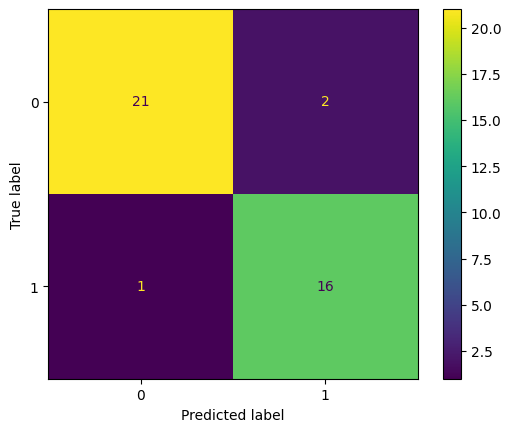

In [ ]:

# Matriz de confusão
cm = confusion_matrix(y_test,predicao)
print(cm)
print("------------------------------------------------------------------")
print(f"TP: {cm[0][0]} | FP: {cm[1][0]} | FN: {cm[0][1]} | TN: {cm[1][1]}")
matrix_display = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=model.classes_)
matrix_display.plot()
plt.show()


In [ ]:
y_test_tt = y_test[y_test == 0]
y_test_tt.count()

np.int64(23)

## Acurácia

In [ ]:
acuracia = accuracy_score(y_test,predicao)
print(f"O percenteual de acurária do modelo é de {acuracia:.2f}%")

O percenteual de acurária do modelo é de 0.93%


## Recall - Sensibilidade

In [ ]:
sencibilidade = recall_score(y_test,predicao)
print(f"O nivel de sensibilidade do modelo é de {sencibilidade:.2f}%")

O nivel de sensibilidade do modelo é de 0.94%


In [ ]:
especificidade = recall_score(y_test,predicao,pos_label=0)
print(f"O nivel de especificade do modelo é de {especificidade:.2f}%")

O nivel de especificade do modelo é de 0.91%


## Precisão

In [ ]:
precisao = precision_score(y_test,predicao)
print(f"O nivel de precisão do modelo é de {precisao:.2f}%")

O nivel de acurária do modelo é de 0.89%


## Curva ROC AUC

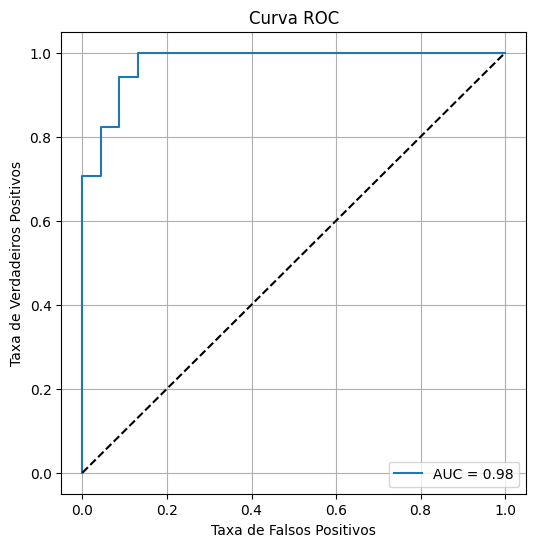

In [ ]:
# Probabilidades previstas pelo modelo (necessárias para ROC)
y_prob = model.predict_proba(X_test)[:, 1]

# Calculando FPR, TPR e thresholds para Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculando a AUC
auc_score = roc_auc_score(y_test, y_prob)

# Plotando a Curva ROC
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0, 1], [0, 1], 'k--')  # Linha diagonal (modelo aleatório)
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid()
plt.show()

## AUC Score

In [ ]:
auc_score = roc_auc_score(y_test,y_prob)
print(f"O nivel de auc_roc do modelo é de {auc_score:.2f}%")

O nivel de auc_roc do modelo é de 0.98%
